In [ ]:
!nvidia-smi

Tue Aug 12 15:15:03 2025       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.247.01             Driver Version: 535.247.01   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA GeForce RTX 4090        On  | 00000000:65:00.0 Off |                  Off |
| 41%   56C    P2             196W / 450W |   7001MiB / 24564MiB |     55%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

In [ ]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "1"

In [ ]:
!pip install --upgrade supervision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.2/207.2 kB 17.3 MB/s eta 0:00:00


# Test large model rfdetr

In [ ]:
from rfdetr import RFDETRLarge

# Khai báo đường dẫn tới bộ dữ liệu training và validation
my_dataset_path = "dataset"

# Khởi tạo model
model = RFDETRLarge()

# Gọi hàm train với tham số đã điều chỉnh
model.train(
    # --- Cấu hình cơ bản ---
    dataset_dir=my_dataset_path,
    epochs=50,
    batch_size=4,
    grad_accum_steps=4,

    # --- Kỹ thuật chống overfitting & Tăng tốc học ---

    # 1. Learning Rate và Scheduler
    lr=1e-4,
    lr_scheduler='cosine',
    lr_warmup_epochs=5,

    # 2. Regularization
    weight_decay=1e-4,

    # 3. Early Stopping (Đã điều chỉnh)
    early_stopping_patience=20, # Giữ ở mức hợp lý
    early_stopping_metric='mAP',
    # THÊM MỚI: Đặt mức cải thiện tối thiểu để reset patience
    early_stopping_min_delta=0.05,

    # 4. Advanced Data Augmentation
    use_mosaic=True,

    # MỚI: Bật tính năng làm mờ ảnh (Blur Augmentation)
    use_blur=True
)

print("Hoàn tất quá trình training!")

2025-08-12 15:15:20.237457: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-12 15:15:20.250284: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-08-12 15:15:20.264648: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-08-12 15:15:20.268948: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-08-12 15:15:20.280460: I tensorflow/core/platform/cpu_feature_guar

Loading pretrain weights


num_classes mismatch: model has 90 classes, but your dataset has 2 classes
reinitializing your detection head with 2 classes.


TensorBoard logging initialized. To monitor logs, use 'tensorboard --logdir output' and open http://localhost:6006/ in browser.
Not using distributed mode
git:
  sha: N/A, status: clean, branch: N/A

Namespace(num_classes=2, grad_accum_steps=4, amp=True, lr=0.0001, lr_encoder=0.00015, batch_size=4, weight_decay=0.0001, epochs=50, lr_drop=100, clip_max_norm=0.1, lr_vit_layer_decay=0.8, lr_component_decay=0.7, do_benchmark=False, dropout=0, drop_path=0.0, drop_mode='standard', drop_schedule='constant', cutoff_epoch=0, pretrained_encoder=None, pretrain_weights='rf-detr-large.pth', pretrain_exclude_keys=None, pretrain_keys_modify_to_load=None, pretrained_distiller=None, encoder='dinov2_windowed_base', vit_encoder_num_layers=12, window_block_indexes=None, position_embedding='sine', out_feature_indexes=[2, 5, 8, 11], freeze_encoder=False, layer_norm=True, rms_norm=False, backbone_lora=False, force_no_pretrain=False, dec_layers=3, dim_feedforward=2048, hidden_dim=384, sa_nheads=12, ca_nheads=

fatal: not a git repository (or any of the parent directories): .git


Epoch: [0]  [  0/115]  eta: 0:05:56  lr: 0.000100  class_error: 82.69  loss: 15.0161 (15.0161)  loss_ce: 0.0747 (0.0747)  loss_bbox: 1.3179 (1.3179)  loss_giou: 2.2633 (2.2633)  loss_ce_0: 0.0670 (0.0670)  loss_bbox_0: 1.3752 (1.3752)  loss_giou_0: 2.3632 (2.3632)  loss_ce_1: 0.0723 (0.0723)  loss_bbox_1: 1.2802 (1.2802)  loss_giou_1: 2.2895 (2.2895)  loss_ce_enc: 0.0704 (0.0704)  loss_bbox_enc: 1.4997 (1.4997)  loss_giou_enc: 2.3428 (2.3428)  loss_ce_unscaled: 0.0747 (0.0747)  class_error_unscaled: 82.6923 (82.6923)  loss_bbox_unscaled: 0.2636 (0.2636)  loss_giou_unscaled: 1.1316 (1.1316)  cardinality_error_unscaled: 3318.7500 (3318.7500)  loss_ce_0_unscaled: 0.0670 (0.0670)  loss_bbox_0_unscaled: 0.2750 (0.2750)  loss_giou_0_unscaled: 1.1816 (1.1816)  cardinality_error_0_unscaled: 2966.2500 (2966.2500)  loss_ce_1_unscaled: 0.0723 (0.0723)  loss_bbox_1_unscaled: 0.2560 (0.2560)  loss_giou_1_unscaled: 1.1447 (1.1447)  cardinality_error_1_unscaled: 3214.5000 (3214.5000)  loss_ce_enc_uns

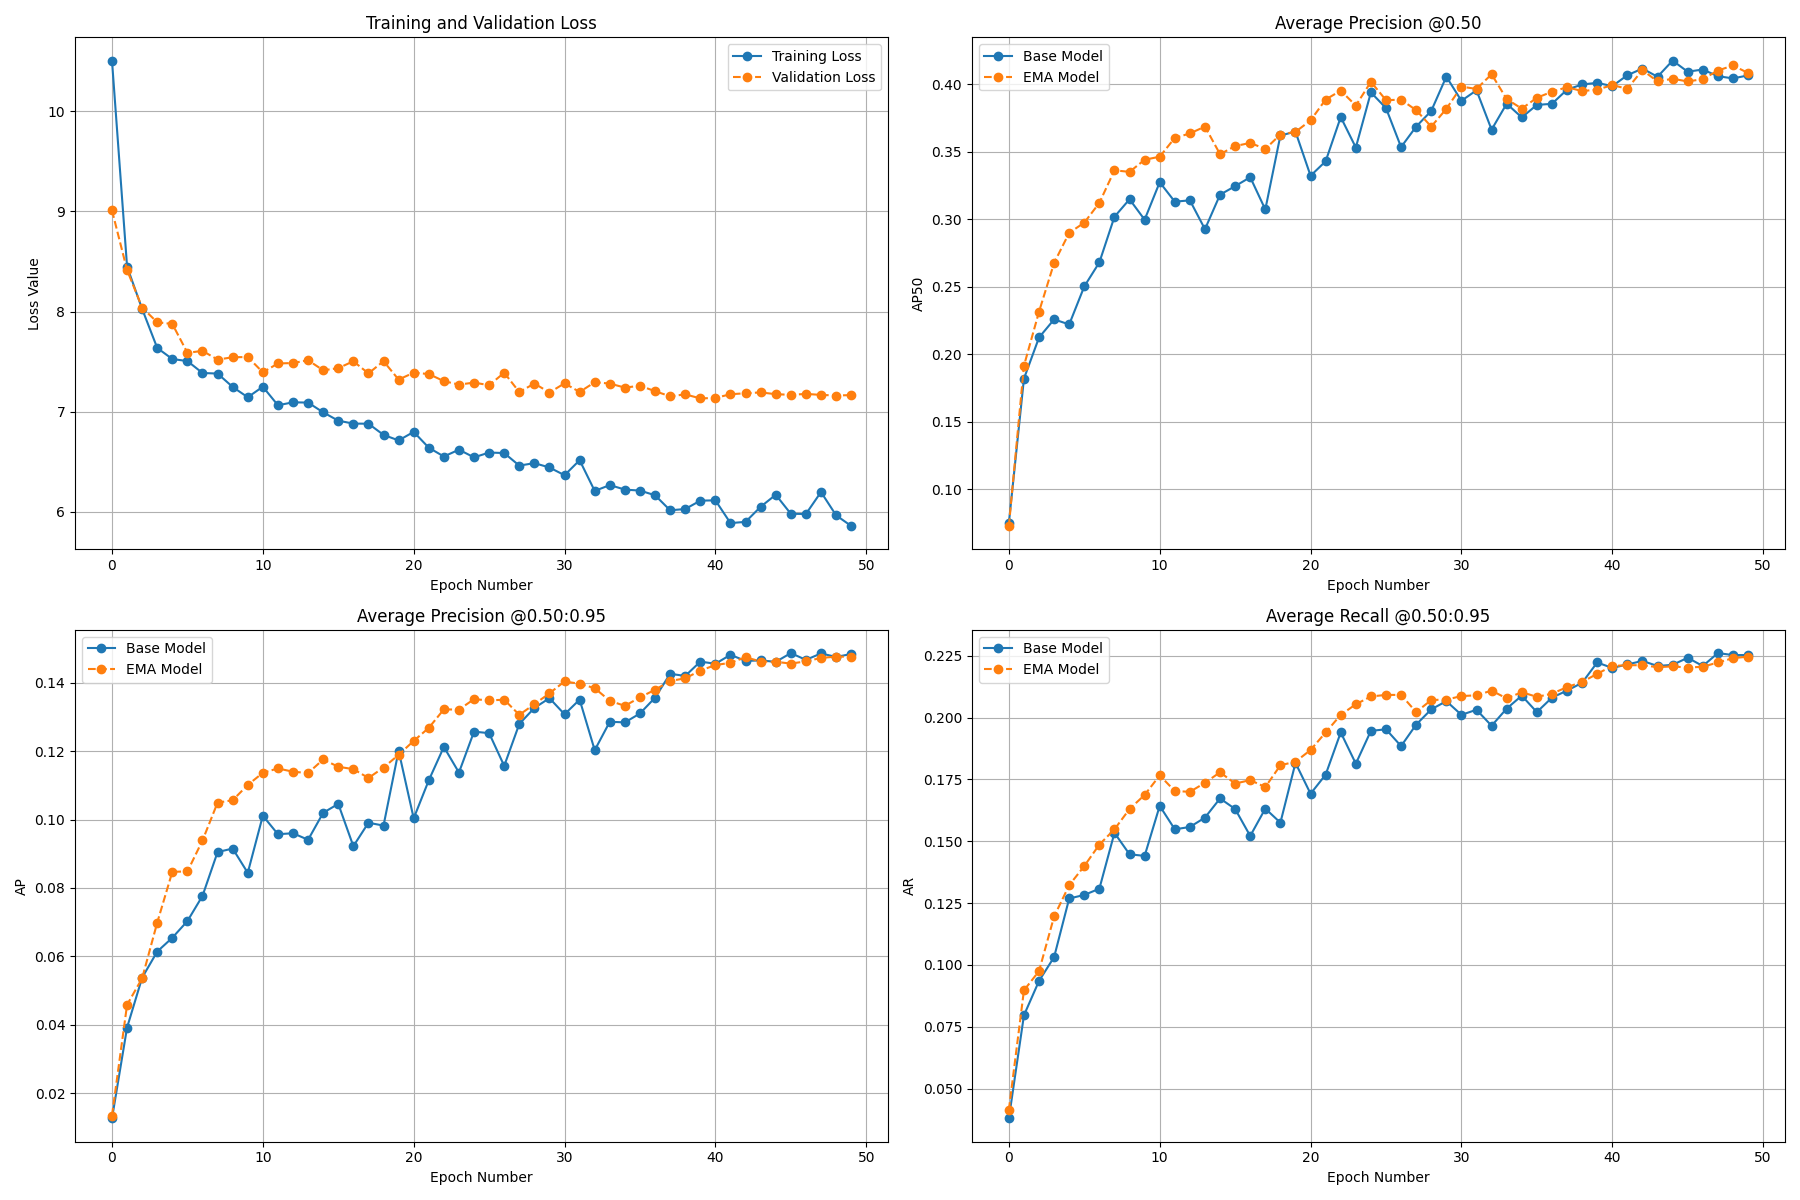

In [ ]:
from PIL import Image

Image.open("output/metrics_plot.png")

In [ ]:
import cv2
import os
import supervision as sv
from PIL import Image
import numpy as np

# Đường dẫn tới thư mục chứa các video test
video_directory_path = "test/test_videos"
output_directory_path = "predict-50-large"  # Đường dẫn tới thư mục lưu video đã xử lý

# Gán trực tiếp danh sách các lớp
class_names = ["human", "cigarette"]  # Danh sách các lớp mà mô hình của bạn nhận dạng được

# Lấy danh sách tất cả các tệp video trong thư mục
video_files = [f for f in os.listdir(video_directory_path) if f.endswith('.mp4')]

# Kiểm tra nếu không có video nào
if not video_files:
    print("Không tìm thấy video trong thư mục.")
else:
    # Tiến hành xử lý từng video trong thư mục
    for video_file in video_files:
        video_input_path = os.path.join(video_directory_path, video_file)
        video_output_path = os.path.join(output_directory_path, f"processed_{video_file}")

        # Mở video
        cap = cv2.VideoCapture(video_input_path)

        # Kiểm tra nếu video mở thành công
        if not cap.isOpened():
            print(f"Không thể mở video {video_file}")
            continue

        # Lấy thông tin về video (kích thước khung hình và số khung hình mỗi giây)
        frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        fps = int(cap.get(cv2.CAP_PROP_FPS))

        # Khởi tạo writer để lưu video mới
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        out = cv2.VideoWriter(video_output_path, fourcc, fps, (frame_width, frame_height))

        # Tiến hành xử lý từng khung hình trong video
        while True:
            ret, frame = cap.read()

            if not ret:
                break

            # Chuyển đổi khung hình từ OpenCV (BGR) sang PIL (RGB)
            image = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

            # Dự đoán đối tượng trong khung hình bằng mô hình đã huấn luyện
            detections = model.predict(image, threshold=0.5)

            # Tính toán độ dày đường viền và kích thước chữ tối ưu
            text_scale = sv.calculate_optimal_text_scale(resolution_wh=image.size)
            thickness = sv.calculate_optimal_line_thickness(resolution_wh=image.size)

            # Tạo annotator cho bounding box và label
            bbox_annotator = sv.BoxAnnotator(thickness=thickness)
            label_annotator = sv.LabelAnnotator(
                text_color=sv.Color.BLACK,
                text_scale=text_scale,
                text_thickness=thickness,
                smart_position=True
            )

            # Gắn nhãn cho các đối tượng phát hiện, kiểm tra class_id trước khi truy cập class_names
            detections_labels = []
            for class_id, confidence in zip(detections.class_id, detections.confidence):
                if class_id >= len(class_names):
                    print(f"Warning: class_id {class_id} exceeds available class names. Assigning label 'Unknown'.")
                    detections_labels.append(f"Unknown {confidence:.2f}")
                else:
                    detections_labels.append(f"{class_names[class_id]} {confidence:.2f}")

            # Tạo bản sao khung hình và vẽ bounding box và nhãn
            frame_with_detections = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2BGR)
            frame_with_detections = bbox_annotator.annotate(frame_with_detections, detections)
            frame_with_detections = label_annotator.annotate(frame_with_detections, detections, detections_labels)

            # Ghi khung hình đã có bounding box vào video output
            out.write(frame_with_detections)

        # Giải phóng tài nguyên
        cap.release()
        out.release()

        print(f"Video {video_file} đã được xử lý và lưu tại {video_output_path}.")

Video 20240601172251_9.mp4 đã được xử lý và lưu tại predict-50-large/processed_20240601172251_9.mp4.
Video 20240701071934_3(1).mp4 đã được xử lý và lưu tại predict-50-large/processed_20240701071934_3(1).mp4.
Video 20240601094113_5_resized.mp4 đã được xử lý và lưu tại predict-50-large/processed_20240601094113_5_resized.mp4.
Video 20240701071649_2.mp4 đã được xử lý và lưu tại predict-50-large/processed_20240701071649_2.mp4.
Video 20240901174405_3.mp4 đã được xử lý và lưu tại predict-50-large/processed_20240901174405_3.mp4.
Video 20240901081026_2_3.mp4 đã được xử lý và lưu tại predict-50-large/processed_20240901081026_2_3.mp4.
Video 20240601135458_12.mp4 đã được xử lý và lưu tại predict-50-large/processed_20240601135458_12.mp4.
Video 20240701071934_3(2).mp4 đã được xử lý và lưu tại predict-50-large/processed_20240701071934_3(2).mp4.
Video 20240901072041_4.mp4 đã được xử lý và lưu tại predict-50-large/processed_20240901072041_4.mp4.


In [ ]:
import shutil
import os

# Đường dẫn tới thư mục cần nén
folder_path = 'predict-50-large'  # Thay thế bằng đường dẫn thực tế của bạn
zip_file_path = 'predict-50-large.zip'  # Đường dẫn tệp zip sẽ được lưu

# Nén thư mục thành file .zip
shutil.make_archive(zip_file_path.replace('.zip', ''), 'zip', folder_path)

# Đưa tệp zip lên thư mục hiện tại của Jupyter
import shutil
from IPython.display import FileLink

# Tạo liên kết tải về tệp zip
FileLink(zip_file_path)

/mnt/8tb_hdd/trash_detection/truong/RFDETR_model/679-cigarette/predict-50-large.zip